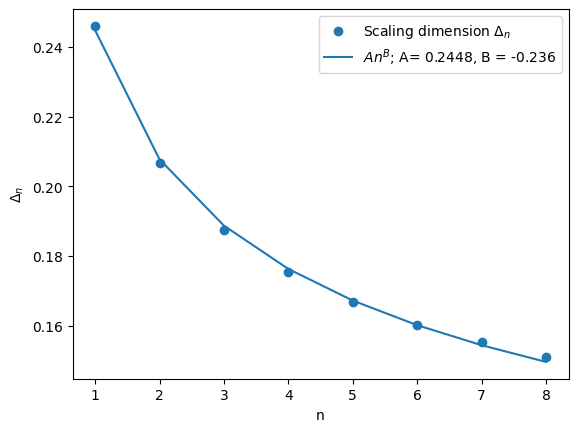

In [43]:
import sys
import os
from time import time

sys.path.append("../../src/")
import numpy as np
import numpy.linalg as la
from itertools import combinations
from scipy.linalg import toeplitz
from collections import Counter  
from matplotlib.pyplot import plot
import matplotlib.pyplot as plt
import kblock_ising_model as kb

from scipy.integrate import solve_ivp

#Compare to other method
#Import
import single_particle_sector as sps
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter


In [73]:
##Time Evolution functions
def h_linear(t,tau,h0,hf):
    #Creates a linear quench from h0 to hf then holds

    if t <= tau:
        return h0-(h0-hf)*(t/tau)
    else:
        return hf
def TFIM_time_evolve(N_steps,tau, h0,hf, J, L, U0= None, bc = "ABC"):
    
    def rhs(t, U_flat, h_t, tau, h0, hf, J,bc):
        h = h_linear(t,tau,h0,hf)
        H = sps.H_bdg(h,L,J)
        U = U_flat.reshape(2*L,2*L)
        dUdt = -1j*2*H@U
        return dUdt.flatten()
    
    #No input vector then grab initial ground state
    if U0 == None:
        H0 = sps.H_bdg(h0,L,J,boundary_condition= bc)
        _,U0 = la.eigh(H0)
    #ABSOLUTELY NECESSARY STEP
   # print(type(U0))
    U0 = U0.astype(np.complex128) 
    #solver stuff 
    args = (h_linear,tau,h0,hf,J,bc)
    t_grid = np.linspace(0,tau,N_steps)
    sol = solve_ivp(rhs, [0, tau], U0.flatten(), args=args, t_eval=t_grid, method="RK45", vectorized=False, dtype=np.complex128)
    
    
    U_t = np.array([sol.y[:, i].reshape(2*L, 2*L) for i in range(len(sol.t))])
    #print(sol.message)
    return U_t


In [127]:
#Model Parameters
N_steps = 100
avg_n = 6
L = 100
h0 = 30
hf = 0
J = 1.0
parity=True
taus = np.logspace(-2,3,100)

taus

array([1.00000000e-02, 1.12332403e-02, 1.26185688e-02, 1.41747416e-02,
       1.59228279e-02, 1.78864953e-02, 2.00923300e-02, 2.25701972e-02,
       2.53536449e-02, 2.84803587e-02, 3.19926714e-02, 3.59381366e-02,
       4.03701726e-02, 4.53487851e-02, 5.09413801e-02, 5.72236766e-02,
       6.42807312e-02, 7.22080902e-02, 8.11130831e-02, 9.11162756e-02,
       1.02353102e-01, 1.14975700e-01, 1.29154967e-01, 1.45082878e-01,
       1.62975083e-01, 1.83073828e-01, 2.05651231e-01, 2.31012970e-01,
       2.59502421e-01, 2.91505306e-01, 3.27454916e-01, 3.67837977e-01,
       4.13201240e-01, 4.64158883e-01, 5.21400829e-01, 5.85702082e-01,
       6.57933225e-01, 7.39072203e-01, 8.30217568e-01, 9.32603347e-01,
       1.04761575e+00, 1.17681195e+00, 1.32194115e+00, 1.48496826e+00,
       1.66810054e+00, 1.87381742e+00, 2.10490414e+00, 2.36448941e+00,
       2.65608778e+00, 2.98364724e+00, 3.35160265e+00, 3.76493581e+00,
       4.22924287e+00, 4.75081016e+00, 5.33669923e+00, 5.99484250e+00,
      

In [128]:
U=TFIM_time_evolve(N_steps,100, h0,hf, J, L, U0= None, bc = "ABC")



/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_12208/2451995446.py:15: RuntimeWarning: divide by zero encountered in matmul
  dUdt = -1j*2*H@U
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_12208/2451995446.py:15: RuntimeWarning: overflow encountered in matmul
  dUdt = -1j*2*H@U
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_12208/2451995446.py:15: RuntimeWarning: invalid value encountered in matmul
  dUdt = -1j*2*H@U


In [131]:
G_test = [sps.G_tfim(U[i][:,L:]) for i in range(0,N_steps)]
Hf = sps.H_bdg(hf,L,J,boundary_condition= True)
_,Uf= la.eigh(Hf)
Gf = sps.G_tfim(Uf[:,L:])

In [132]:
ground_state_strings = np.empty(10)
ns = np.array([1,2,3,4,5,6,7,8,9,10])
time_evolved_strings = np.empty([10,len(G_test)])

for n in ns:
    ground_state_strings[n-1] = sps.P_n(n,Gf,L)
    for i in range(len(G_test)):
        time_evolved_strings[n-1,i] = sps.P_n(n,G_test[i],L)



In [138]:
dat =(time_evolved_strings.T-ground_state_strings)[-1,:]

In [121]:
def expected_deviation(tau,n):
    a = 0.2448
    b = -0.236
    dev = tau**(-a/2*n**b)
    return dev

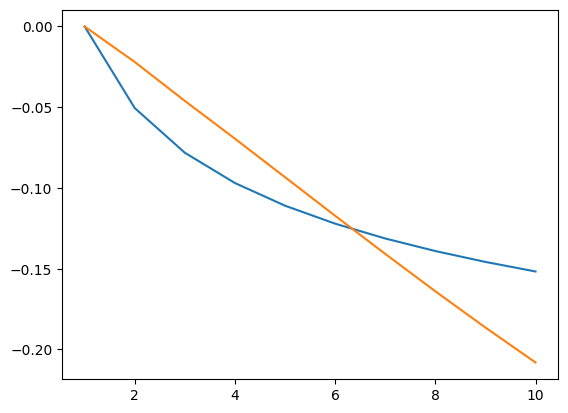

In [156]:
test = [-expected_deviation(100,n)+expected_deviation(100,1) for n in ns]

plot(ns,test)
plot(ns,dat)